# Shopper Spectrum: Customer Segmentation and Product Recommendation

## Day 1 - Dataset Understanding, Data Cleaning and Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to understand the dataset, perform data cleaning, create useful features, and analyze customer purchasing behavior through exploratory data analysis.

# 1. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# 2. Load Dataset

In [6]:
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


# 3. Dataset Overview

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


# 4. Statistical Summary

In [8]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2023-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


# 5. Missing Values Analysis

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# 6. Duplicate Records Analysis

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


# 7. Data Cleaning

### Cleaning Steps
- Remove rows with missing CustomerID
- Remove cancelled invoices
- Remove transactions with Quantity <= 0
- Remove transactions with UnitPrice <= 0

In [11]:
df = df.dropna(subset=["CustomerID"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (397884, 8)


# 8. Feature Engineering

### Create Total Transaction Amount

In [12]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# 9. Transaction Volume by Country

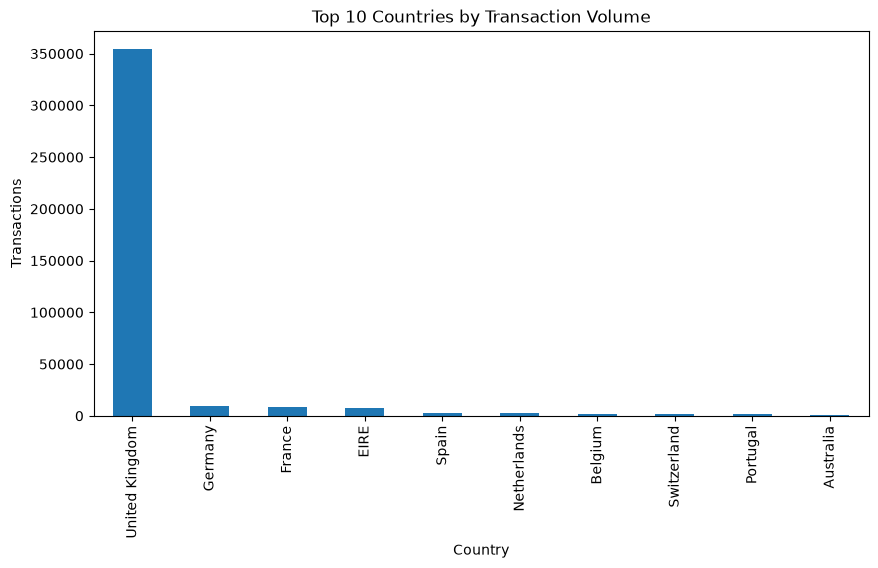

In [13]:
country_transactions = (
    df.groupby("Country")["InvoiceNo"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

country_transactions.plot(kind="bar")

plt.title("Top 10 Countries by Transaction Volume")
plt.xlabel("Country")
plt.ylabel("Transactions")

plt.show()

### Observation

- The United Kingdom contributes the highest number of transactions.
- Most purchases are concentrated in a few countries.
- International transactions are comparatively lower than domestic transactions.
- This indicates that the business has a strong customer base in the United Kingdom.

# 10. Top Selling Products

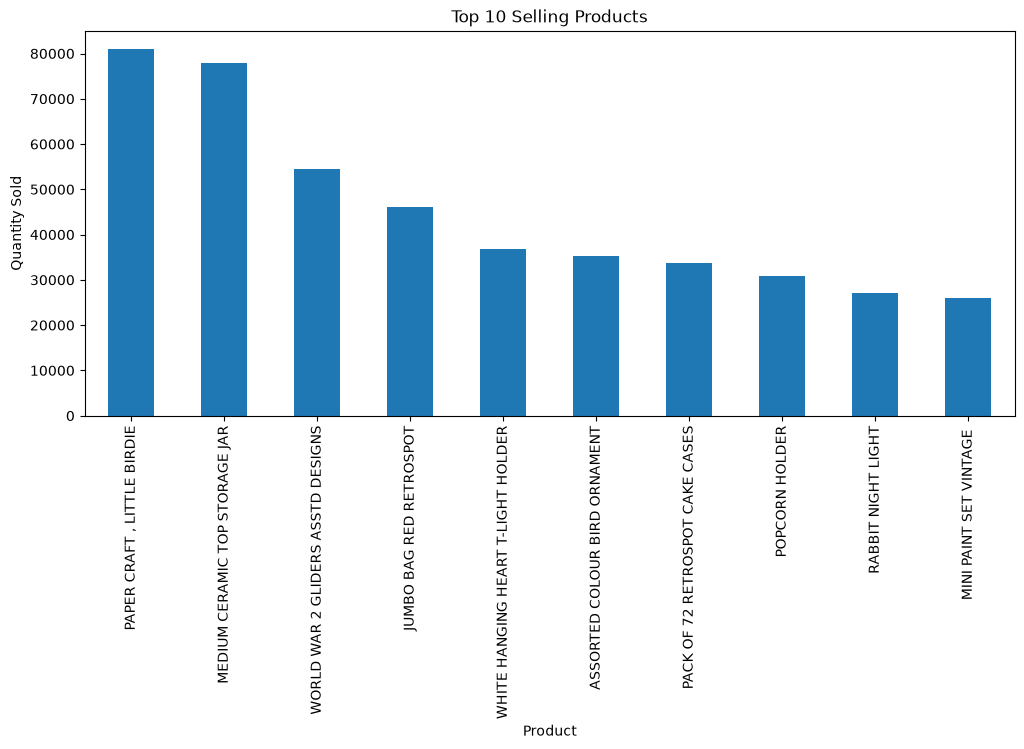

In [14]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

### Observation

- A small number of products account for a large share of total sales volume.
- These products represent the most popular items among customers.
- High-demand products should be prioritized for inventory planning.
- Product popularity can be leveraged for recommendation strategies.

# 11. Purchase Trends Over Time

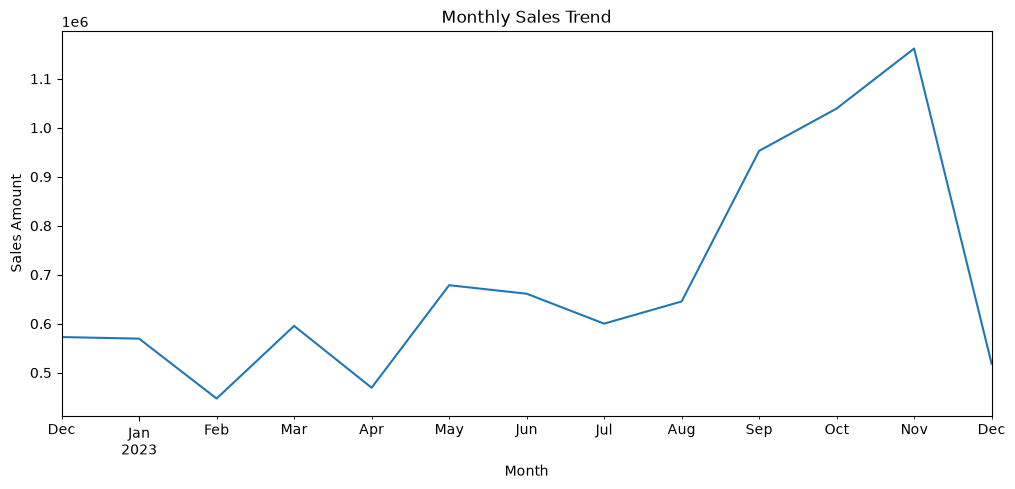

In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["TotalAmount"]
      .sum()
)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")

plt.show()

### Observation

- Sales vary across different months, indicating changing customer demand.
- Certain periods show higher purchasing activity than others.
- Seasonal trends may influence customer buying behavior.
- Understanding these trends helps in planning marketing campaigns and inventory.

# 12. Transaction Amount Distribution

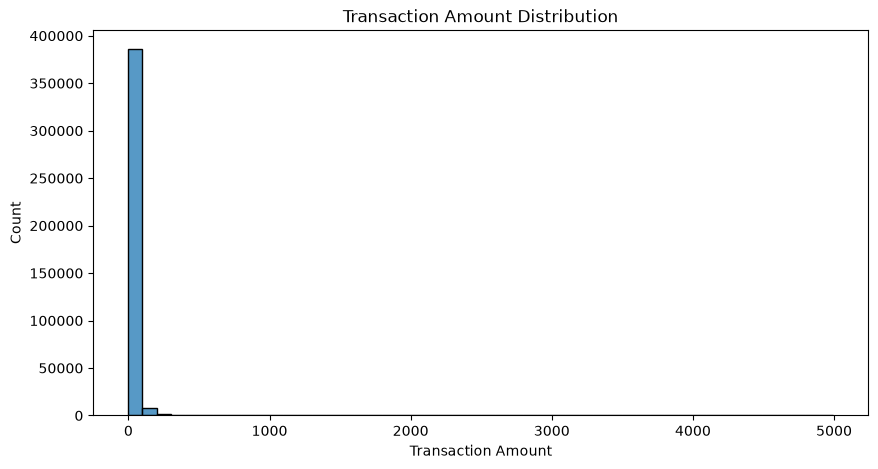

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df["TotalAmount"] < 5000]["TotalAmount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

plt.show()

### Observation

- Most transactions fall within a lower spending range.
- A small number of transactions contribute exceptionally high purchase amounts.
- The distribution is positively skewed due to high-value purchases.
- This suggests the presence of both regular and premium customers.

# Key Insights

- Data cleaning removed missing customer records and invalid transactions.
- The United Kingdom is the dominant market in terms of transaction volume.
- A few products generate a significant portion of overall sales.
- Customer spending behavior is highly varied, with both low-value and high-value purchases.
- Purchase activity changes over time, indicating possible seasonal effects.
- These insights will be used in the next phase for RFM-based customer segmentation and product recommendation.